In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\50_Startups.csv')

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.isnull()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [6]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [7]:
df.rename(columns={'R&D Spend':'Spend','Marketing Spend':'Marketing'},inplace=True)           

In [8]:
x=df.drop(columns=["Profit","State"])
x.head()

,Spend,Administration,Marketing
0,165349.20,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42


In [9]:
y=df["Profit"]
y.head()

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64

In [10]:
import statsmodels.formula.api as smf

In [11]:
model1=smf.ols('y~Spend+Administration+Marketing',data=x).fit()

In [12]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     296.0
Date:                Sat, 07 Oct 2023   Prob (F-statistic):           4.53e-30
Time:                        17:09:59   Log-Likelihood:                -525.39
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      46   BIC:                             1066.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       5.012e+04   6572.353      7.626      0.000    3.69e+04    6.34e+04
Spend              0.8057      0.045     17.846      0.000       0.715       0.897
Administration    -0.0268      0.051     -0.526      0.602      -0.130       0.076
Marketing          0.0272      0.016      1.655      0.105      -0.006       0.060
==============================================================================
Omnibus:                       14.838   Durbin-Watson:                   1.282
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.442
Skew:                          -0.949   Prob(JB):                     2.21e-05
Kurtosis:                       5.586   Cond. No.                     1.40e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.4e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lm=LinearRegression()

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [17]:
lm.fit(X_train,Y_train)

LinearRegression()

In [18]:
y_predict_train=lm.predict(X_train)
y_predict_train

array([160136.96930361, 150181.63601236,  47165.53108055,  44488.48943544,
       102434.18075449, 145006.02381207,  97913.15425076,  98040.86284406,
       116194.83732626,  68774.55738733, 115640.10975582,  59787.16007991,
       152140.1442941 , 127311.25274765, 102237.77258191, 161184.19036111,
       130654.40218885,  74290.61817989,  47509.05258118, 189615.91220478,
       128447.25198992,  85062.41354634, 110850.82613475, 157447.67674777,
       108684.98330427,  75372.87394935, 118604.71839325, 115540.83448865,
       152892.34013692,  81001.94886382,  56416.42813917, 172286.72314823,
       192214.72908284,  46666.27433881,  65689.34055377])

In [19]:
y_predict_test=lm.predict(X_test)
y_predict_test

array([104054.44293869, 132719.3459701 , 133640.26830949,  72294.76911458,
       179685.62227843, 114508.97572031,  66305.23069863,  98297.69326565,
       114277.91894933, 169112.36095691,  96257.40152149,  87916.97242208,
       110687.33942598,  90670.8337806 , 127780.63539583])

In [20]:
lm.coef_

array([0.79045925, 0.03114407, 0.03137206])

In [21]:
lm.intercept_

42448.52861957178

In [22]:
lm.predict([[165349.20,136897.80,471784.10]])

C:\Users\SHYAM SASHANK\anaconda3\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([192214.72908284])

In [23]:
MLR=0.79045925*165349.20+136897.80*0.03114407+471784.10*0.03137206+42448.52861957178
MLR

192214.7269979638

In [24]:
from sklearn.metrics import mean_squared_error

In [25]:
y_predict_train.shape

(35,)

In [26]:
y_predict_test.shape

(15,)

In [27]:
y_predict_train= np.array(y_predict_train.reshape(-1,1))
y_predict_train

array([[160136.96930361],
       [150181.63601236],
       [ 47165.53108055],
       [ 44488.48943544],
       [102434.18075449],
       [145006.02381207],
       [ 97913.15425076],
       [ 98040.86284406],
       [116194.83732626],
       [ 68774.55738733],
       [115640.10975582],
       [ 59787.16007991],
       [152140.1442941 ],
       [127311.25274765],
       [102237.77258191],
       [161184.19036111],
       [130654.40218885],
       [ 74290.61817989],
       [ 47509.05258118],
       [189615.91220478],
       [128447.25198992],
       [ 85062.41354634],
       [110850.82613475],
       [157447.67674777],
       [108684.98330427],
       [ 75372.87394935],
       [118604.71839325],
       [115540.83448865],
       [152892.34013692],
       [ 81001.94886382],
       [ 56416.42813917],
       [172286.72314823],
       [192214.72908284],
       [ 46666.27433881],
       [ 65689.34055377]])

In [28]:
y_predict_train.shape

(35, 1)

In [29]:
y_predict_test.shape

(15,)

In [30]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

In [31]:
print("train is: " + str(["%.8f" % elem for elem in y_predict_train]))
print("test is: " + str(["%.8f" % elem for elem in y_predict_test]))


rmse_val = rmse(np.array(y_predict_train), np.array(y_predict_test))
print("rms error is: " + str(rmse_val))

train is: ['160136.96930361', '150181.63601236', '47165.53108055', '44488.48943544', '102434.18075449', '145006.02381207', '97913.15425076', '98040.86284406', '116194.83732626', '68774.55738733', '115640.10975582', '59787.16007991', '152140.14429410', '127311.25274765', '102237.77258191', '161184.19036111', '130654.40218885', '74290.61817989', '47509.05258118', '189615.91220478', '128447.25198992', '85062.41354634', '110850.82613475', '157447.67674777', '108684.98330427', '75372.87394935', '118604.71839325', '115540.83448865', '152892.34013692', '81001.94886382', '56416.42813917', '172286.72314823', '192214.72908284', '46666.27433881', '65689.34055377']
test is: ['104054.44293869', '132719.34597010', '133640.26830949', '72294.76911458', '179685.62227843', '114508.97572031', '66305.23069863', '98297.69326565', '114277.91894933', '169112.36095691', '96257.40152149', '87916.97242208', '110687.33942598', '90670.83378060', '127780.63539583']
rms error is: 52102.22737255637


In [32]:
model2=smf.ols('y~Spend',data=x).fit()

In [33]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Sat, 07 Oct 2023   Prob (F-statistic):           3.50e-32
Time:                        17:10:03   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.903e+04   2537.897     19.320      0.000    4.39e+04    5.41e+04
Spend          0.8543      0.029     29.151      0.000       0.795       0.913
==============================================================================
Omnibus:                       13.727   Durbin-Watson:                   1.116
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.536
Skew:                          -0.911   Prob(JB):                     9.44e-05
Kurtosis:                       5.361   Cond. No.                     1.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [34]:
df.corr()

,Spend,Administration,Marketing,Profit
Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


In [35]:
model3=smf.ols('y~Administration',data=x).fit()

In [36]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     2.015
Date:                Sat, 07 Oct 2023   Prob (F-statistic):              0.162
Time:                        17:10:05   Log-Likelihood:                -599.63
No. Observations:                  50   AIC:                             1203.
Df Residuals:                      48   BIC:                             1207.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       7.697e+04   2.53e+04      3.040      0.004    2.61e+04    1.28e+05
Administration     0.2887      0.203      1.419      0.162      -0.120       0.698
==============================================================================
Omnibus:                        0.126   Durbin-Watson:                   0.099
Prob(Omnibus):                  0.939   Jarque-Bera (JB):                0.110
Skew:                           0.093   Prob(JB):                        0.947
Kurtosis:                       2.866   Cond. No.                     5.59e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.59e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
model4=smf.ols('y~Marketing',data=x).fit()

In [38]:
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     60.88
Date:                Sat, 07 Oct 2023   Prob (F-statistic):           4.38e-10
Time:                        17:10:05   Log-Likelihood:                -580.18
No. Observations:                  50   AIC:                             1164.
Df Residuals:                      48   BIC:                             1168.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept       6e+04   7684.530      7.808      0.000    4.46e+04    7.55e+04
Marketing      0.2465      0.032      7.803      0.000       0.183       0.310
==============================================================================
Omnibus:                        4.420   Durbin-Watson:                   1.178
Prob(Omnibus):                  0.110   Jarque-Bera (JB):                3.882
Skew:                          -0.336   Prob(JB):                        0.144
Kurtosis:                       4.188   Cond. No.                     4.89e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.89e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [39]:
#The R-Squared Values for the total data

from sklearn.metrics import r2_score
score = r2_score(Y_test,y_predict_test)
print("The accuracy of our model is {}%".format(round(score, 2) *100))

The accuracy of our model is 94.0%


In [40]:
#MultiCollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [41]:
def cal_vif(x):
    
    #calculating the VIF Values
    vif=pd.DataFrame()
    vif["Variables"]=x.columns=['Spend','Administration','Marketing']
    vif["Cal_Vif"]=[VIF(x.values, i) for i in range(x.shape[1])]
    
    return(vif)

In [42]:
x1=x.iloc[:,:-1]
cal_vif(x)             #Here the cal_vif values are high for all the variables 

,Variables,Cal_Vif
0,Spend,8.384571
1,Administration,4.026406
2,Marketing,7.593984


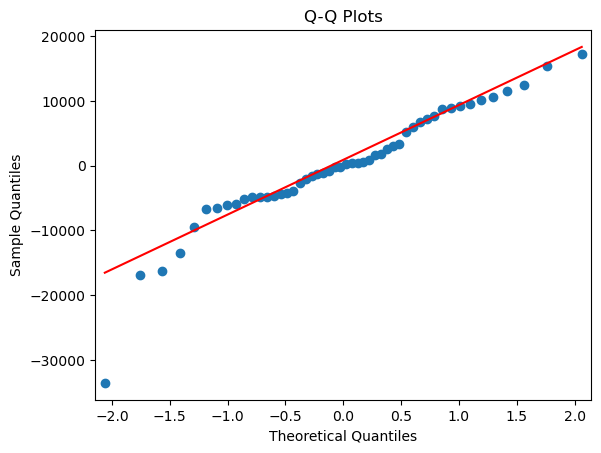

In [43]:
# Q-Q Plotting

import statsmodels.api as sm

qplot=sm.qqplot(model1.resid,line='q')
plt.title("Q-Q Plots")
plt.show()

# Model Deletion Diagnostics

[3.21825244e-05 3.27591036e-03 3.23842699e-02 2.17206555e-02
 1.44833032e-02 1.17158463e-02 2.91766303e-03 3.56513444e-03
 4.04303948e-05 4.86758017e-03 1.51064757e-02 1.63564959e-02
 1.15516625e-02 4.01422811e-03 6.12934253e-02 3.40013448e-02
 8.33556413e-03 3.30534399e-03 2.16819303e-03 4.07440577e-02
 4.25137222e-04 1.09844352e-02 2.91768000e-03 2.76030254e-04
 5.04643588e-03 3.00074623e-03 3.41957068e-03 2.98396413e-02
 1.31590664e-03 1.25992620e-04 4.18505125e-05 9.27434786e-06
 7.08656521e-04 1.28122674e-04 2.09815032e-02 6.69508674e-03
 5.55314705e-02 6.55050578e-05 5.61547311e-02 1.54279607e-03
 1.84850929e-03 1.97578066e-03 1.36089280e-04 2.05553171e-02
 1.23156041e-04 9.03234206e-02 5.45303387e-02 5.33885616e-03
 1.90527441e-01 2.88082293e-01] [1.         0.99997771 0.99791128 0.99904583 0.9995713  0.99971836
 0.99998231 0.99997361 1.         0.9999509  0.99953404 0.99945472
 0.99972613 0.99996657 0.99282118 0.99770282 0.99985673 0.99997731
 0.99999022 0.99673318 0.99999962 0

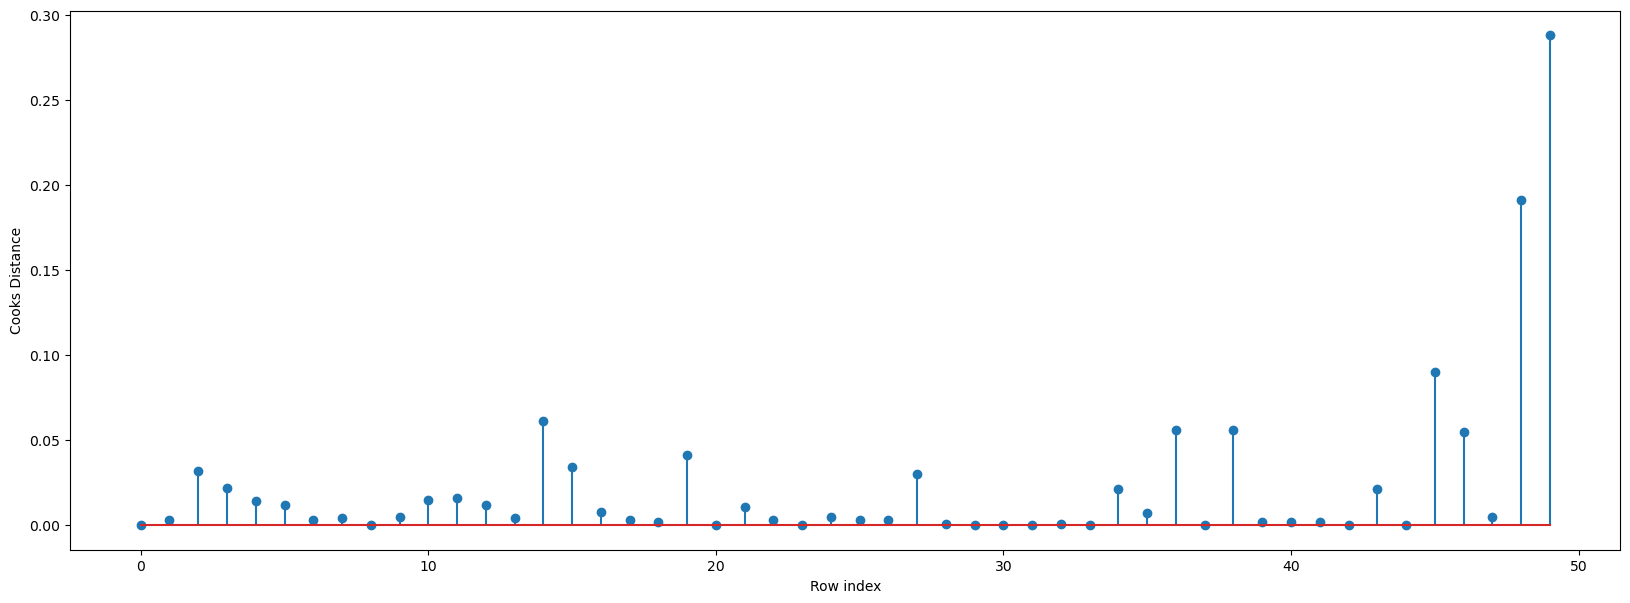

In [44]:
#Cook's Distance

from statsmodels.graphics.regressionplots import influence_plot

influence=model1.get_influence()  # Create the variable for the model1

(c, _) = influence.cooks_distance  #Creating cooks variable 
print(c, _)

#visualizing the cook's Distance

fig = plt.subplots(figsize=(20, 7))
plt.stem(np.arange(len(df)), np.round(c, 3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')
plt.show()

In [45]:
# Hat-Points/ Leverage/ Influence

k=df.shape[1]
n=df.shape[0]

leverage_cutoff=3*((k+1)/n)
leverage_cutoff

0.36

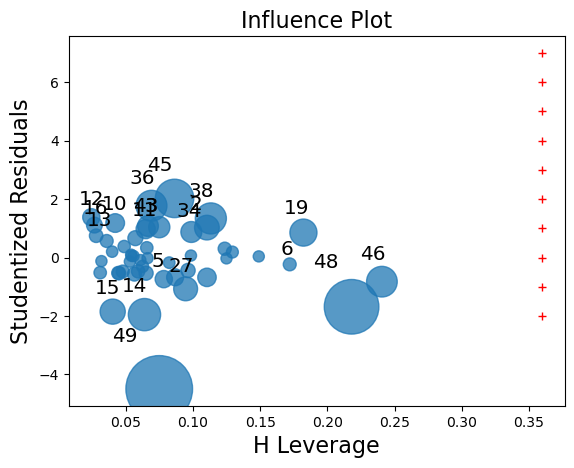

In [46]:
# Plotting the Influence

influence_plot(model1,alpha=0.5)

y1=[i for i in range(-2,8)]
x2=[leverage_cutoff for i in range(10)]

plt.plot(x2,y1,'r+')
plt.show()

In [47]:
#There is no influence data points in the dataset

model1.rsquared

0.9507459940683246

In [65]:
from sklearn import linear_model

#importing the Ridge
reg=linear_model.Ridge(alpha=3)
reg.fit(X_train,Y_train)

Ridge(alpha=3)

In [66]:
reg.coef_

array([0.79045925, 0.03114407, 0.03137206])

In [67]:
lm_coefficient=pd.DataFrame()
lm_coefficient["Columns"] = X_train.columns 
lm_coefficient['Normal_lm_Coeff'] = pd.Series(lm.coef_) 

ridge_coeff=pd.DataFrame()
ridge_coeff["Columns"]= X_train.columns
ridge_coeff['Ridge_Reg_Coeff'] = pd.Series(reg.coef_)

print(lm_coefficient) 
print("\n ")
print(ridge_coeff)

          Columns  Normal_lm_Coeff
0           Spend         0.790459
1  Administration         0.031144
2       Marketing         0.031372

 
          Columns  Ridge_Reg_Coeff
0           Spend         0.790459
1  Administration         0.031144
2       Marketing         0.031372


In [77]:
# Lasso 
las=linear_model.Lasso(alpha=3)
las.fit(X_train,Y_train)
las.coef_

array([0.79045926, 0.03114407, 0.03137206])

In [79]:
lasso_coeff=pd.DataFrame()
lasso_coeff["Columns"]=X_train.columns
lasso_coeff['Lasso_coeff']= pd.Series(las.coef_)

print(lasso_coeff)

          Columns  Lasso_coeff
0           Spend     0.790459
1  Administration     0.031144
2       Marketing     0.031372
